# 25.04.03修改耦合mechCoupling=0.45->0.1

In [ ]:
import time
import numpy as np
import os
import sys
# 将目录添加到 Python 路径
sys.path.append('/DATACENTER4/jiangbo.chai/SWJTU_OOPAO')
from OOPAO.Atmosphere import Atmosphere
from OOPAO.DeformableMirror import DeformableMirror
from OOPAO.Source import Source
from OOPAO.Telescope import Telescope
from OOPAO.ShackHartmann import ShackHartmann
from tutorials.scao_system.myAoSystem.Imager import Imager  # 导入科学相机模块
import matplotlib.pyplot as plt
import OOPAO.tools.displayTools as tools

In [10]:
ngs = Source(magnitude=5,optBand='H')

# 创建望远镜
tel = Telescope(resolution          = 120, # 分辨率
                diameter            = 8, # 直径
                samplingTime        = 1/1000, # 采样时间
                centralObstruction  = 0) # 中心遮挡比例
ngs * tel
atm = Atmosphere(
    telescope=tel,
    r0=0.15,  # 大气湍流的弗里德参数（Fried parameter），表示大气相干长度，单位为米
    L0=30,# 大气湍流的外尺度（Outer scale），单位为米
    altitude=[0,4000,10000],# 每个湍流层的海拔高度，单位为米
    fractionalR0=[0.7,0.25,0.05], # 每个湍流层的 Cn² 剖面，表示每个层对总湍流的贡献比例
    windSpeed=[5,10,20],# 每个湍流层的风速，单位为米/秒
    windDirection=[0,90,360])# 每个湍流层的风向，单位为度

%%%%%%%%%%%%%%%%%%%%%%%%%%%%% SOURCE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
 Source Wavelength Zenith  Azimuth   Altitude Magnitude    Flux   
           [m]    [arcsec]  [deg]      [m]              [phot/m2/s]
-------------------------------------------------------------------
  NGS   1.654e-06    0        0        inf       5.0    29891304.3
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% TELESCOPE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
     Diameter             8                [m]        
    Resolution           120             [pixels]     
    Pixel Size           0.07              [m]        
     Surface             50.0              [m2]       
Central Obstruction        0          [% of diameter]  
Pixels in the pupil      11304            [pixels]     
      Source             None                         
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
No light propagated through the telescope


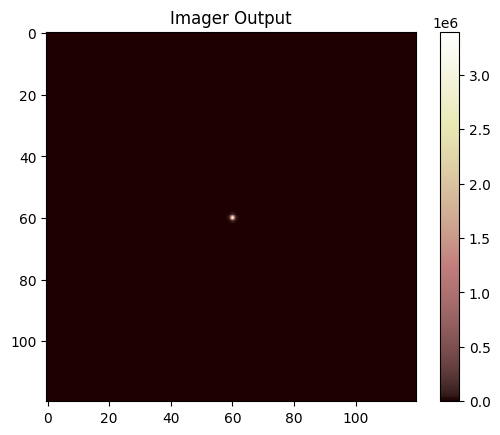

In [11]:
tel-atm
camH = Imager() # 创建科学相机
camH.clock_rate = 1000 # 时钟频率
camH.exposure_time = 0.2 # 曝光时间
camH.relay(tel.src)
camH.reference_frame = camH.frame # 无湍流情况下的图片
camH.display()

-> Computing the initial phase screen...
initial phase screen : 0.010209083557128906 s


ZZt.. : 1.910141944885254 s
ZXt.. : 0.2442762851715088 s
XXt.. : 0.12391209602355957 s
Done!
-> Computing the initial phase screen...
initial phase screen : 0.008078336715698242 s
ZZt.. : 7.152557373046875e-07 s
ZXt.. : 2.288818359375e-05 s
XXt.. : 6.9141387939453125e-06 s
SCAO system considered: covariance matrices were already computed!
Done!
-> Computing the initial phase screen...
initial phase screen : 0.007533073425292969 s
ZZt.. : 4.76837158203125e-07 s
ZXt.. : 1.7881393432617188e-05 s
XXt.. : 7.152557373046875e-06 s
SCAO system considered: covariance matrices were already computed!
Done!


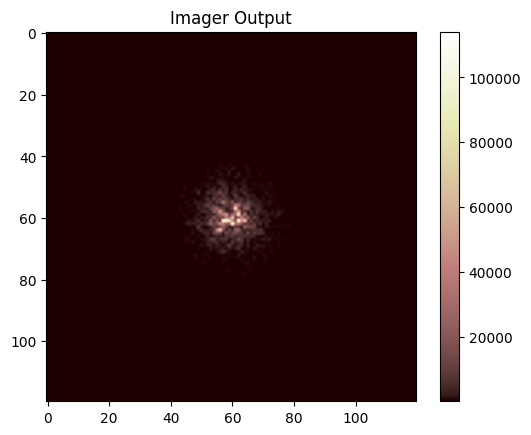

In [12]:
atm.initializeAtmosphere(telescope=tel)
tel+atm
camH.relay(tel.src)
camH.display()

In [13]:
# print(np.max(camH.frame),np.max(camH.reference_frame))
# print(np.sum(camH.frame/np.max(camH.reference_frame)))
# print(np.sum(camH.frame/np.max(camH.frame)))
# print(np.sum(camH.reference_frame/np.max(camH.reference_frame)))

In [14]:
camH.strehl

0.0336169688710269

In [15]:
# 创建变形镜
dm=DeformableMirror(telescope    = tel,
                    nSubap       = 20, # 沿望远镜直径的变形镜驱动器数，即总驱动数=nSubap*nSubap
                    mechCoupling = 0.1) # 驱动器之间的机械耦合系数,用于描述变形镜的各个驱动器之间的机械相互作用程度
# 创建SH-WFS 

wfs = ShackHartmann(nSubap              = 20, #  沿望远镜直径的子孔径数
                    telescope           = tel,
                    lightRatio          = 0.3, # 用于筛选有效子孔径
                    is_geometric        = False, # 是否启用几何模式（直接测量梯度）
                    threshold_cog       = 0.01) # 计算光斑质心时的阈值
gainCL                  = 0.6  # 传感增益

No coordinates loaded.. taking the cartesian geometry as a default
Generating a Deformable Mirror: 
Computing the 2D zonal modes...
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%% DEFORMABLE MIRROR %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Controlled Actuators        357        
         M4                False       
        Pitch               0.4               [m]        
 Mechanical Coupling        0.1               [%]        
-------------------------------------------------------------------------------
Mis-registration:
Rotation [deg]	Shift X [m]	Shift Y [m]	Radial Scaling [%]	Tangential Scaling [%]
      0       	     0     	     0     	        0         	          0           
%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Selecting valid subapertures based on flux considerations..


In [16]:
from OOPAO.calibration.ao_calibration import ao_calibration
from tutorials.scao_system.parameter_files.parameterFile_VLT_I_Band_SHWFS import initializeParameterFile

param = initializeParameterFile()

'''
加载或生成模态基,即模式到控制矩阵（M2C）用于将模式映射到变形镜（DM）的控制信号
计算或加载交互矩阵
'''
ao_calib =  ao_calibration(param            = param,\
                           ngs              = ngs,\
                           tel              = tel,\
                           atm              = atm,\
                           dm               = dm,\
                           wfs              = wfs,\
                           nameFolderIntMat = None,\
                           nameIntMat       = None,\
                           nameFolderBasis  = None,\
                           nameBasis        = None,\
                           nMeasurements    = 100)


Reading/Writting calibration data from data_calibration/
Writting output data in data_cl/
Loading the KL Modal Basis from: data_calibration/M2C_120_res
ERROR: No file found! Taking a zonal basis instead..
Loading Interaction matrix data_calibration/VLT_I_band_20x20/zonal_interaction_matrix_120_res_332_subap_diffractive...


Done!
No Modal Gains found. All gains set to 1


Loop 1/200 - Elapsed time: 0.06 s
Turbulence: 772.89 nm -- Residual: 772.89 nm -- SR: 0.03

Loop 2/200 - Elapsed time: 0.06 s
Turbulence: 773.62 nm -- Residual: 773.62 nm -- SR: 0.04

Loop 3/200 - Elapsed time: 0.07 s
Turbulence: 774.36 nm -- Residual: 385.66 nm -- SR: 0.18

Loop 4/200 - Elapsed time: 0.07 s
Turbulence: 775.12 nm -- Residual: 127.27 nm -- SR: 0.79

Loop 5/200 - Elapsed time: 0.07 s
Turbulence: 775.92 nm -- Residual: 237.99 nm -- SR: 0.43

Loop 6/200 - Elapsed time: 0.08 s
Turbulence: 776.72 nm -- Residual: 186.33 nm -- SR: 0.60

Loop 7/200 - Elapsed time: 0.07 s
Turbulence: 777.46 nm -- Residual: 127.83 nm -- SR: 0.79

Loop 8/200 - Elapsed time: 0.07 s
Turbulence: 778.22 nm -- Residual: 196.25 nm -- SR: 0.57

Loop 9/200 - Elapsed time: 0.07 s
Turbulence: 779.01 nm -- Residual: 215.38 nm -- SR: 0.51

Loop 10/200 - Elapsed time: 0.07 s
Turbulence: 779.80 nm -- Residual: 177.71 nm -- SR: 0.63

Loop 11/200 - Elapsed time: 0.07 s
Turbulence: 780.61 nm -- Residual: 137.99 nm

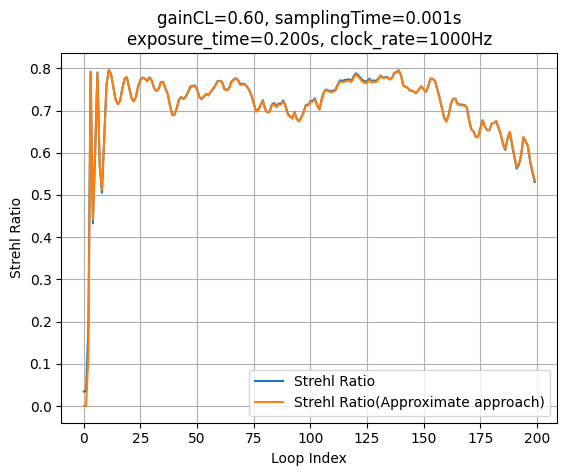

In [17]:
# 闭环控制
calib_CL    = ao_calib.calib # 交互矩阵
M2C_CL      = ao_calib.M2C

tel+atm
ngs*tel*dm*wfs
# initialize DM commands
dm.coefs=0


param['nLoop'] = 200
# 初始化参数
SR                      = np.zeros(param['nLoop']) # 斯特列尔比
total                   = np.zeros(param['nLoop'])
residual                = np.zeros(param['nLoop'])
wfsSignal               = np.arange(0,wfs.nSignal)*0

wfs.cam.photonNoise = True  # 启用光子噪声

# 分配内存以保存数据
SR = np.zeros(param['nLoop'])  # 斯特列尔比
SR_old = np.zeros(param['nLoop'])  # 近似方式斯特列尔比
total = np.zeros(param['nLoop'])  # 总波前误差
residual = np.zeros(param['nLoop'])  # 残余波前误差
wfsSignal = np.zeros(wfs.nSignal)  # 波前传感器信号

# 初始化变形镜控制信号
dm.coefs = 0
gainCL = 0.6  # 闭环控制增益
# 主循环
for i in range(param['nLoop']):
    start_time = time.time()

    # 更新大气湍流相位屏
    atm.update()

    # 记录总的波前误差
    total[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9

    # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 波前传感器
    ngs * tel * dm * wfs

    # 更新变形镜控制信号
    dm.coefs = dm.coefs - gainCL * M2C_CL @ calib_CL.M @ wfsSignal

    # 更新波前传感器信号
    wfsSignal = wfs.signal
    # 记录残余波前误差
    residual[i] = np.std(tel.OPD[np.where(tel.pupil > 0)]) * 1e9
    # # 光波传播：自然引导星 -> 望远镜 -> 变形镜 -> 科学相机
    # ngs * tel * dm
    # tel * dm
    camH.relay(tel.src)
    # camH.display()
    # if i % 4 == 0:
    #     camH.display()
        # plt.figure()
        # plt.imshow(tel.src.phase)
        # plt.show()

    SR[i] = camH.strehl  # 科学相机计算的斯特列尔比
    SR_old[i]=np.exp(-np.var(tel.src.phase[np.where(tel.pupil==1)]))


    # 打印结果
    elapsed_time = time.time() - start_time
    print(f'Loop {i+1}/{param["nLoop"]} - Elapsed time: {elapsed_time:.2f} s')
    print(f'Turbulence: {total[i]:.2f} nm -- Residual: {residual[i]:.2f} nm -- SR: {SR[i]:.2f}\n')

ngs*tel * dm
# camH.relay(tel.src)
# camH.display()
# 绘制斯特列尔比随时间的变化

plt.figure()
plt.plot(np.arange(param['nLoop']), SR, label='Strehl Ratio')
plt.plot(np.arange(param['nLoop']), SR_old, label='Strehl Ratio(Approximate approach)')
plt.xlabel('Loop Index')
plt.ylabel('Strehl Ratio')
plt.title(  f"gainCL={gainCL:.2f}, "
            f"samplingTime={tel.samplingTime:.3f}s\n"
            f"exposure_time={camH.exposure_time:.3f}s, "
            f"clock_rate={camH.clock_rate:.0f}Hz")
plt.legend()
plt.grid()
plt.show()